In [30]:
from pathlib import Path
import json
import math

# Geometry / chemistry config
R_UNIT = 'angstrom'
BASIS = 'sto-3g'
MULTIPLICITY = 1
CHARGE = 0

# VQE config
cfg = {
    'layers': 3,
    'shots': 4096,
    'max_iters': 50,
    'learning_rate': 0.2,
    'seed': 7,
    'gradient_method': 'autograd',
    'prefer_chips': 'Simulator',
    'shift': math.pi / 2,
}


In [31]:
from quantum_hw import QuantumHardwareClient
from quantum_hw.algorithms import VQERunner
from quantum_hw.circuit import QuantumCircuit

def build_h2_ucc_style_symbolic_ansatz() -> QuantumCircuit:
    qc = QuantumCircuit(4)

    # -------------------------
    # Hartree–Fock reference
    # |1100>
    # -------------------------

    qc.x(0)
    qc.x(1)

    # basis rotation
    qc.h(0)
    qc.h(1)
    qc.h(2)
    qc.sdg(3)
    qc.h(3)

    # CNOT ladder
    qc.cx(0,1)
    qc.cx(1,2)
    qc.cx(2,3)

    qc.rz("theta",3)

    qc.cx(2,3)
    qc.cx(1,2)
    qc.cx(0,1)

    # undo basis
    qc.h(0)
    qc.h(1)
    qc.h(2)
    qc.h(3)
    qc.s(3)

    return qc

custom_ansatz_qc = build_h2_ucc_style_symbolic_ansatz()
symbolic_params = sorted(
    [k for k, v in custom_ansatz_qc.params_value.items() if isinstance(k, str) and isinstance(v, str)]
)
print('Total gates in custom H2-UCC-style ansatz:', len(custom_ansatz_qc.gates))

Total gates in custom H2-UCC-style ansatz: 19


In [32]:
from __future__ import annotations

import os
import json
from pathlib import Path

# Work around duplicated OpenMP runtime loading on Windows notebook kernels.
os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

from quantum_hw import QuantumHardwareClient
from quantum_hw.algorithms import VQERunner
import numpy as np

R_range = np.arange(0.5, 3.01, 0.3)
energy_he = []
energy_ucc = []
for r, R in enumerate(R_range):
    json_path = Path(f'data/chemistry/h2_R{R:.1f}_angstrom_sto-3g.json')
    if not json_path.exists():
        raise FileNotFoundError(
            f'Missing {json_path}. Generate it in WSL with:\n'
            'python scripts/export_h2_terms_wsl.py --R 2.6 --unit angstrom '
            '--output data/chemistry/h2_R2.6_angstrom_sto-3g.json'
        )

    data = json.loads(json_path.read_text(encoding='utf-8'))

    h2_constant = float(data['constant'])
    h2_4q_terms = [(float(c), str(obs)) for c, obs in data['terms']]
    nqubits = int(data['nqubits'])
    fci_energy = float(data['fci_energy'])

    print('Loaded from:', json_path)

    client = QuantumHardwareClient()
    runner = VQERunner(
        client=client,
        shots=cfg['shots'],
        max_iters=cfg['max_iters'],
        learning_rate=cfg['learning_rate'],
        gradient_method=cfg['gradient_method'],
        seed=cfg['seed'],
    )

    result = runner.run_model(
        name=f'h2_4q_R{R:.1f}_he',
        num_qubits=nqubits,
        model='custom',
        hamiltonian=h2_4q_terms,
        prefer_chips=cfg['prefer_chips'],
        ansatz='hardwareefficient',
    )

    best_total_energy = h2_constant + result.best_energy
    abs_error_fci = abs(best_total_energy - fci_energy)
    energy_he.append({
        'R': R,
        'estimated_total_energy': best_total_energy,
    })

    result = runner.run_model(
        name=f'h2_4q_R{R:.1f}_ucc',
        num_qubits=nqubits,
        model='custom',
        hamiltonian=h2_4q_terms,
        prefer_chips=cfg['prefer_chips'],
        ansatz='custom',
        custom_ansatz_circuit=custom_ansatz_qc,
        init_params=[0]*len(symbolic_params)
        
    )

    best_total_energy = h2_constant + result.best_energy
    abs_error_fci = abs(best_total_energy - fci_energy)
    energy_ucc.append({
        'R': R,
        'estimated_total_energy': best_total_energy,
    })


Loaded from: data\chemistry\h2_R0.5_angstrom_sto-3g.json
[vqe] prepare run: name=h2_4q_R0.5_he num_qubits=4 model=custom layers=1 shots=4096 max_iters=50
[vqe] candidate chips: ['Simulator']
[vqe] running on chip: Simulator
[vqe] start optimization: iters=50 layers=1 params=16 ansatz=hardwareefficient shots=4096 shift=1.5707963267948966 gradient=autograd
[vqe] iter 0 start
[vqe] iter 0 energy=0.263824 grad_norm=0.481480
[vqe] iter 0 new best energy=0.263824
[vqe] iter 1 start
[vqe] iter 1 energy=0.018042 grad_norm=0.323647
[vqe] iter 1 new best energy=0.018042
[vqe] iter 2 start
[vqe] iter 2 energy=-0.135297 grad_norm=0.271324
[vqe] iter 2 new best energy=-0.135297
[vqe] iter 3 start
[vqe] iter 3 energy=-0.261158 grad_norm=0.292600
[vqe] iter 3 new best energy=-0.261158
[vqe] iter 4 start
[vqe] iter 4 energy=-0.363588 grad_norm=0.314201
[vqe] iter 4 new best energy=-0.363588
[vqe] iter 5 start
[vqe] iter 5 energy=-0.451775 grad_norm=0.333610
[vqe] iter 5 new best energy=-0.451775
[vqe]

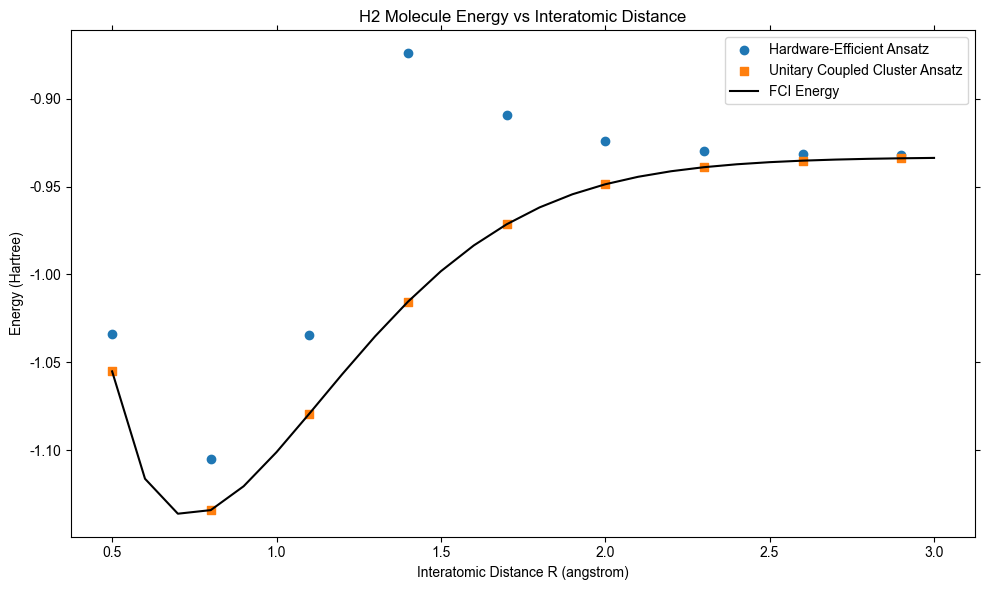

In [33]:
from matplotlib import pyplot as plt

R_values = [res['R'] for res in energy_he]
estimated_energies_he = [res['estimated_total_energy'] for res in energy_he]
estimated_energies_ucc = [res['estimated_total_energy'] for res in energy_ucc]
R_range = np.arange(0.5, 3.01, 0.1)
fci_energies = []
for R in R_range:
    json_path = Path(f'data/chemistry/h2_R{R:.1f}_angstrom_sto-3g.json')
    data = json.loads(json_path.read_text(encoding='utf-8'))
    fci_energies.append(float(data['fci_energy']))
plt.figure(figsize=(10, 6))
plt.scatter(R_values, estimated_energies_he, marker='o', label='Hardware-Efficient Ansatz')
plt.scatter(R_values, estimated_energies_ucc, marker='s', label='Unitary Coupled Cluster Ansatz')
plt.plot(R_range, fci_energies, 'k-', label='FCI Energy')
plt.xlabel('Interatomic Distance R (angstrom)')
plt.ylabel('Energy (Hartree)')
plt.legend()
plt.title('H2 Molecule Energy vs Interatomic Distance')
plt.tick_params(right=True, top=True)
plt.tight_layout()
plt.show()

In [35]:
cfg['prefer_chips'] = 'Yudu'
cfg['zne'] = True
cfg['readout_mitigation'] = True
cfg['clifford_fitting'] = True
cfg['clifford_fitting_num_samples'] = 8
cfg['max_iters'] = 10
cfg['gradient_method'] = 'parameter-shift'
energy_ucc_exp = []
R_range = np.arange(0.5, 3.01, 0.3)
for r, R in enumerate(R_range):
    json_path = Path(f'data/chemistry/h2_R{R:.1f}_angstrom_sto-3g.json')
    if not json_path.exists():
        raise FileNotFoundError(
            f'Missing {json_path}. Generate it in WSL with:\n'
            'python scripts/export_h2_terms_wsl.py --R 2.6 --unit angstrom '
            '--output data/chemistry/h2_R2.6_angstrom_sto-3g.json'
        )

    data = json.loads(json_path.read_text(encoding='utf-8'))

    h2_constant = float(data['constant'])
    h2_4q_terms = [(float(c), str(obs)) for c, obs in data['terms']]
    nqubits = int(data['nqubits'])
    fci_energy = float(data['fci_energy'])

    print('Loaded from:', json_path)

    client = QuantumHardwareClient()
    runner = VQERunner(
        client=client,
        shots=cfg['shots'],
        max_iters=cfg['max_iters'],
        learning_rate=cfg['learning_rate'],
        gradient_method=cfg['gradient_method'],
        seed=cfg['seed'],
        zne=cfg['zne'],
        readout_mitigation=cfg['readout_mitigation'],
        shift=cfg['shift'],
        clifford_fitting=cfg['clifford_fitting'],
        clifford_fitting_num_samples=cfg['clifford_fitting_num_samples'],
    )

    result = runner.run_model(
        name=f'h2_4q_R{R:.1f}_ucc',
        num_qubits=nqubits,
        model='custom',
        hamiltonian=h2_4q_terms,
        prefer_chips=cfg['prefer_chips'],
        ansatz='custom',
        custom_ansatz_circuit=custom_ansatz_qc,
        init_params=[0]*len(symbolic_params)
    )

    best_total_energy = h2_constant + result.best_energy
    abs_error_fci = abs(best_total_energy - fci_energy)
    energy_ucc_exp.append({
        'R': R,
        'estimated_total_energy': best_total_energy,
    })


Loaded from: data\chemistry\h2_R0.5_angstrom_sto-3g.json
[vqe] prepare run: name=h2_4q_R0.5_ucc num_qubits=4 model=custom layers=1 shots=4096 max_iters=10
Yudu configuration loading done!
The last calibration time was 2026-03-14 19:32:25
[vqe] candidate chips: ['Yudu']
Yudu configuration loading done!
The last calibration time was 2026-03-14 19:32:25
[vqe] running on chip: Yudu
[vqe] clifford fitting prepared: terms=14 samples=8
[vqe] start optimization: iters=10 layers=1 params=1 ansatz=custom shots=4096 shift=1.5707963267948966 gradient=parameter-shift
[vqe] iter 0 start
[vqe] iter 0 energy=-1.340426 grad_norm=0.277282
[vqe] iter 0 new best energy=-1.340426
[vqe] iter 1 start
[vqe] iter 1 energy=-1.395815 grad_norm=0.016365
[vqe] iter 1 new best energy=-1.395815
[vqe] iter 2 start
[vqe] iter 2 energy=-1.349972 grad_norm=0.156824
[vqe] iter 3 start
[vqe] iter 3 energy=-1.448172 grad_norm=0.206544
[vqe] iter 3 new best energy=-1.448172
[vqe] iter 4 start
[vqe] iter 4 energy=-1.389191 g

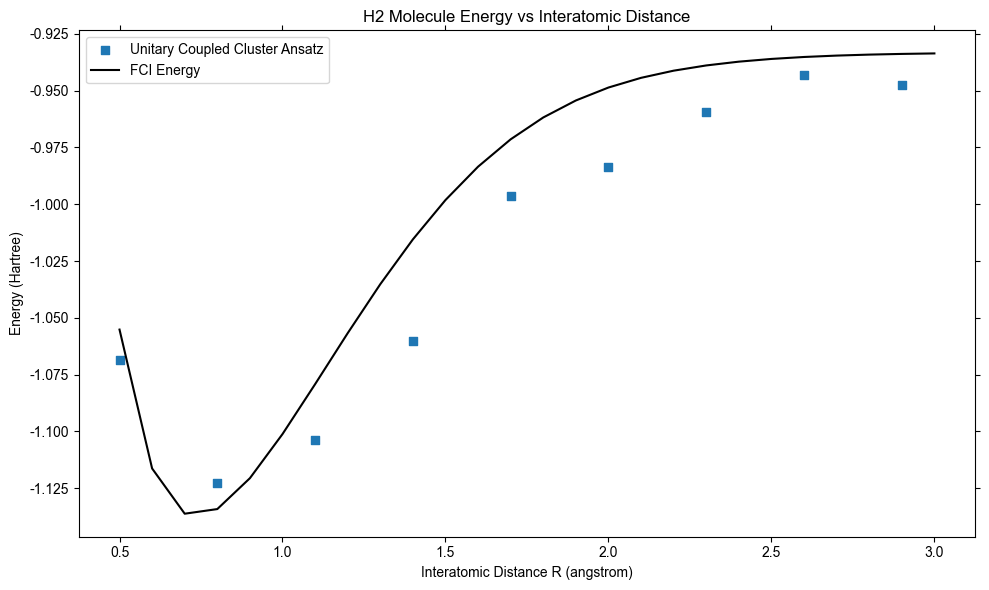

In [36]:
R_values = [res['R'] for res in energy_ucc_exp]
estimated_energies_ucc = [res['estimated_total_energy'] for res in energy_ucc_exp]
R_range = np.arange(0.5, 3.01, 0.1)
fci_energies = []
for R in R_range:
    json_path = Path(f'data/chemistry/h2_R{R:.1f}_angstrom_sto-3g.json')
    data = json.loads(json_path.read_text(encoding='utf-8'))
    fci_energies.append(float(data['fci_energy']))
plt.figure(figsize=(10, 6))
plt.scatter(R_values, estimated_energies_ucc, marker='s', label='Unitary Coupled Cluster Ansatz')
plt.plot(R_range, fci_energies, 'k-', label='FCI Energy')
plt.xlabel('Interatomic Distance R (angstrom)')
plt.ylabel('Energy (Hartree)')
plt.legend()
plt.title('H2 Molecule Energy vs Interatomic Distance')
plt.tick_params(right=True, top=True)
plt.tight_layout()
plt.show()